# A data-driven ring attractor from mouse HD tuning curves

Fits recurrent weights to the measured HD tuning curves, characterizes the resulting
attractor, and tests it against circulant surrogates and a real velocity drive.

**Produces** Figure 2 (`figures/data_driven_attractor.pdf`), assembled in the final cell;
every panel below is a component of it.

**Reads** `data/mouse_data/tc_data.npz`, `data/closing_the_loop.npz`,
`data/convergence_pcs.npz`, `data/convergence_distances.npz`,
`data/surrogate_bump_sims.npz`, `data/surrogate_spectra.npz` and
`data/velocity_integration_sims.npz`.

In [1]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
REGENERATE_CACHES = False
SAVE_FIGURES = False


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from ring import data_driven, style

import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np
import scipy


## Load tuning curves and fit the recurrent weights

Solves for `J` such that the measured tuning curves `X` are a fixed point of the network, i.e. `X ≈ Φ Jᵀ`, with ridge regularization `lamda=1e-8`; the printed error confirms the fit. The resampling runs at `N_theta=10000`.

In [2]:

# Load data
Phi_raw = data_driven.load_data_Phi()

# Compute weights

# Compute 'old' weights
X, Phi = data_driven.prepare_smoothed_normalized_resampled_tuning_curves(Phi_raw, N_theta=10000)
J, J_prime = data_driven.compute_weights(X, Phi, lamda=1e-8)


print("err =", np.mean((X - Phi @ J.T)**2))


err = 1.7152363818838536e-08


## Convergence-to-ring simulation (writes `convergence_pcs.npz`, `convergence_distances.npz`)

Runs 100 noise-perturbed initial conditions to convergence, PCAs the trajectories, and measures each trajectory's distance to the ring. The call only runs when `REGENERATE_CACHES = True`, so a normal run does not overwrite the caches you downloaded. The `np.random.seed(42)` inside the function pins the initial-condition noise, so a rebuild reproduces them.

In [3]:

# Define T and tau
T, tau = 30, 0.05
T_eval = tau / 5.
dt = tau / 50.

def run_convergence_analysis():
    # Run simulation for multiple initial conditions
    N_ics = 100
    noise_std = 3.
    np.random.seed(42)
    x_init_noiseless = X[::int(X.shape[0] / N_ics)].copy().T
    x_init = x_init_noiseless + np.random.randn(*x_init_noiseless.shape) * noise_std
    print(x_init.shape)
    
    x_save = data_driven.run_simulation(J, x_init, T=T, tau=tau, dt=dt, T_eval=T_eval, c_const=1)
    
    # Compute PCA
    pcs, pcs_traj = data_driven.do_pca_on_tcs_and_trajectories(Phi, data_driven.nonlin(x_save))
    np.savez("../data/convergence_pcs.npz", pcs=pcs, pcs_traj=pcs_traj)
    
    # Compute distances
    print("computing distances")
    distances = data_driven.compute_distances_to_ring_batched(
        Phi, data_driven.nonlin(x_save)[:2000], chunk_size=20)
    np.savez("../data/convergence_distances.npz", distances=distances)

if REGENERATE_CACHES:
    run_convergence_analysis()

## The attractor is a ring in PC space (Fig 2, panels e–f)

Projected onto the top three PCs of the tuning curves, the perturbed trajectories collapse onto a closed 1-D ring, and their distance to that ring decays over ~seconds. Both panels read from the caches produced above.

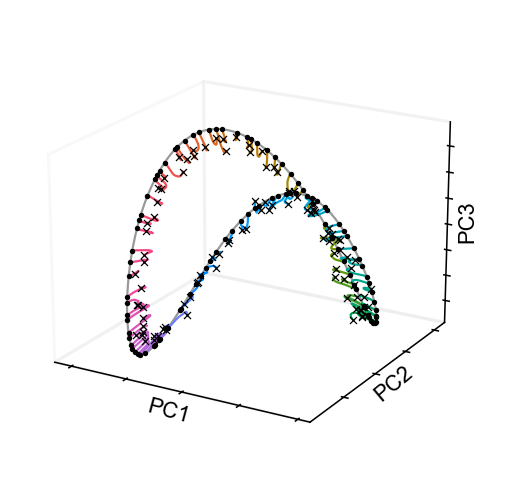

In [4]:

pc_data = np.load("../data/convergence_pcs.npz", "r")
pcs = pc_data['pcs']
pcs_traj = pc_data['pcs_traj']

def plot_pcs(ax):
    # Plot PCA
    data_driven.plot_3d_pca(ax, pcs, pcs_traj)
    ax.set_xlabel("PC1", labelpad=-16, rotation=-15)
    ax.set_ylabel("PC2", labelpad=-17, rotation=40)
    ax.set_zlabel("PC3", labelpad=-17, rotation=90)
    ax.view_init(elev=20, azim=120)

fig = plt.figure(figsize=(2, 2))
ax = plt.subplot(projection='3d')
fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
plot_pcs(ax)
plt.show()

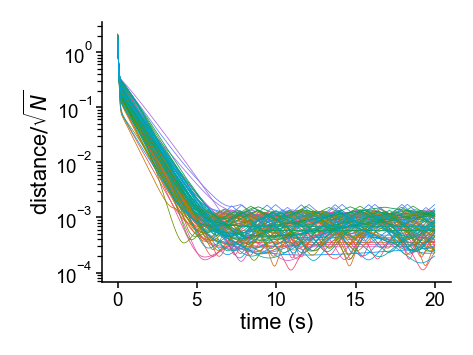

In [5]:
import matplotlib.cm as cm
distances = np.load("../data/convergence_distances.npz", "r")['distances']

# Cyclic angle colormap for the head-direction coloring in panels E-I. A muted,
# desaturated hsv keeps every angle a distinct hue with 0 and 2*pi identical,
# without the harsh pure-hsv rainbow. Centralized in ring.style, which
# plot_3d_pca reads directly.
angle_cmap = style.ANGLE_CMAP

def plot_distances(ax):
    # Plot distances
    n_trajectories = distances.shape[1]
    colors = angle_cmap(np.linspace(0, 1, n_trajectories))
    for ic_idx in range(n_trajectories):
        color = colors[ic_idx]
        ax.plot(np.arange(len(distances))*T_eval, distances[:, ic_idx], c=color, lw=0.25)
    ax.set_yscale('log')
    ax.set_xlabel("time (s)")
    ax.set_ylabel("distance$/\\sqrt{N}$")

fig, ax = plt.subplots(1, 1, figsize=(2, 1.5))
plot_distances(ax)

## Circulant surrogates: how much of the fit matters?

Builds three surrogates of the fitted matrix: sorted by tuning-curve center of mass, circularized (averaging over all circular shifts), and circulant plus the residual noise scrambled, symmetrically or asymmetrically. If the ring survives the surrogates, the fitted structure the network needs is just translation invariance plus noise statistics.

In [6]:
def create_circularized_matrix(J_sorted):
    """Create a circularized version of the sorted weight matrix using efficient row computation."""
    n = J_sorted.shape[0]
    # Compute first row by summing all circular shifts
    first_row = np.zeros_like(J_sorted[0])
    for i in range(n):
        first_row += np.roll(J_sorted[i], -i)
    first_row /= n
    
    # circulant(c) gives C[i,j] = c[i-j]; the diagonal average is f(j-i), so transpose
    return scipy.linalg.circulant(first_row).T

def create_scrambled_noise_matrices(J_sorted, J_circ):
    """Create scrambled noise matrices with symmetric and asymmetric versions."""
    N = J_sorted.shape[0]
    J_noise = J_circ - J_sorted
    idx = np.triu_indices(N, k=1)
    
    z = np.concatenate((J_noise[idx], J_noise.T[idx]))
    np.random.shuffle(z)
    
    J_noise_scrambled = np.zeros_like(J_noise)
    J_noise_scrambled[idx] = z[:len(z)//2]
    J_noise_scrambled.T[idx] = z[len(z)//2:]
    
    J_noise_scrambled_sym = np.zeros_like(J_noise)
    J_noise_scrambled_sym[idx] = z[:len(z)//2]
    J_noise_scrambled_sym.T[idx] = z[:len(z)//2]
    
    return J_noise_scrambled, J_noise_scrambled_sym

def compute_new_matrices(J, Phi):
    """Perform complete network analysis returning all derived matrices."""
    J_sorted, srt_order = data_driven.sort_weight_matrix(J, Phi)
    J_circ = create_circularized_matrix(J_sorted)
    J_noise_scrambled, J_noise_scrambled_sym = create_scrambled_noise_matrices(J_sorted, J_circ)

    SCALE_FACTOR = 1.275
    return {
        'orig': J,
        'srt': J_sorted,
        'circ': SCALE_FACTOR * J_circ,
        'circ_plus_noise': SCALE_FACTOR * (J_circ + J_noise_scrambled),
        'circ_plus_noise_sym': SCALE_FACTOR * (J_circ + J_noise_scrambled_sym),
        'srt_order': srt_order
    }

# Initialization functions
def create_tuning_curve_init(X, n_initial_conditions, noise_std=3.):
    """Create initial conditions from tuning curves with added noise."""
    x_init_noiseless = X[::int(X.shape[0] / n_initial_conditions)].copy().T
    x_init = x_init_noiseless + np.random.randn(*x_init_noiseless.shape) * noise_std
    return x_init

# Simulation function
def run_network_simulation(matrix, x_init, T=30, tau=0.05, dt=None, T_eval=None):
    """Run network simulation with given parameters."""
    if dt is None:
        dt = tau / 50.
    if T_eval is None:
        T_eval = tau / 5.
    
    return data_driven.run_simulation(
        matrix, x_init, T=T, tau=tau, dt=dt, T_eval=T_eval, c_const=1
    )

# Plotting functions
def plot_weight_matrix(ax, matrix, title, vmin=-0.005, vmax=0.005, cmap=style.DIVERGING_CMAP):
    """Plot weight matrix."""
    im = ax.imshow(matrix, vmin=vmin, vmax=vmax, cmap=cmap, interpolation='nearest')
    ax.set_aspect(1.)
    # Minimal neuron-count ticks: the matrix is N x N, so mark the first and last
    # neuron on the y-axis (square aspect makes the x-extent read as the same N).
    N = matrix.shape[0]
    ax.set_xticks([])
    ax.set_yticks([0, N - 1])
    ax.set_yticklabels(["1", str(N)])
    ax.tick_params(axis='y', length=2, width=0.6, labelsize=5, pad=1.5)
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.set_title(title)
    return im


def plot_simulation_results(ax, x_save, title=None, titlepad=0, sigma=2.5, title_y=1.3):
    """Plot simulation results with Gaussian smoothing."""
    smoothed_data = gaussian_filter1d(x_save, sigma=sigma, axis=0)
    num_nrns = x_save.shape[0]
    print(num_nrns)

    phi_smoothed = data_driven.nonlin(smoothed_data)
    n_trajectories = phi_smoothed.shape[1]
    colors = angle_cmap(np.linspace(0, 1, n_trajectories))
    for ic_idx in range(n_trajectories):
        ax.plot(np.arange(num_nrns)+1, phi_smoothed[:, ic_idx], clip_on=False, c=colors[ic_idx], lw=0.25)
    ax.set_xlim(0.5, num_nrns+0.5)
    y = smoothed_data.max()
    print(y)
    ax.set_ylim([0, y*1.6])
    ax.set_yticks([])
    ax.set_xticks([1, num_nrns], ["1", "N"])
    ax.text(num_nrns/2, title_y*y, s=title, ha='center', va='bottom')
    if title == "circulant+noise":
        ax.set_xlabel("neurons (COM order)")
    else:
         ax.set_xlabel("neurons (COM order)", labelpad=-5)
    ax.set_ylabel("firing rate")
    ax.yaxis.set_label_coords(-0.02, 0.35)
    ax.spines['left'].set_visible(False)
    ax.set_facecolor([0,0,0,0])




## Weight matrices (Fig 2, panels a–d)

`create_scrambled_noise_matrices` calls `np.random.shuffle`, so the `np.random.seed(42)` at the top of this cell keeps panel d's `circulant+noise` image the same from run to run.

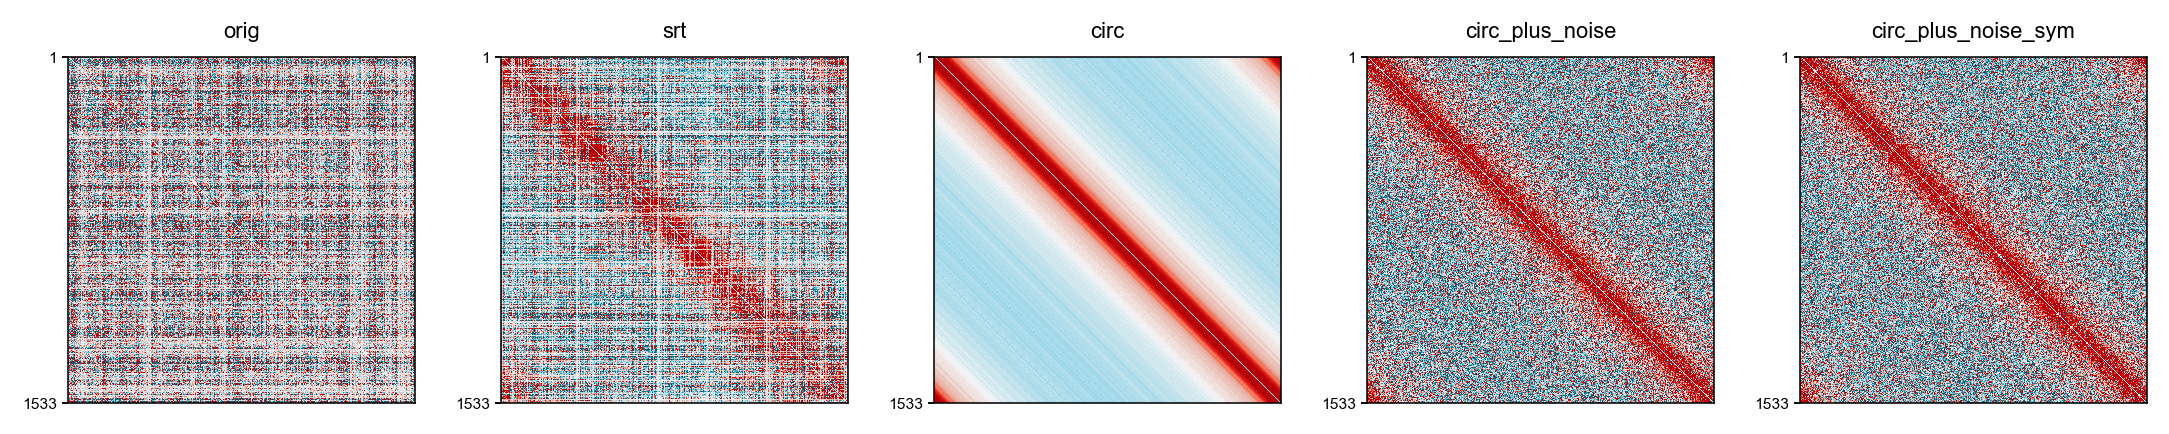

In [7]:
np.random.seed(42)

fig, axes = plt.subplots(1, 5, figsize=(12, 2))

mat_results = compute_new_matrices(J=J, Phi=Phi)
for ax, key in zip(axes, mat_results.keys()):
    plot_weight_matrix(ax, mat_results[key], key)
    ax.set_title(key)

## Bump formation under each surrogate (writes `surrogate_bump_sims.npz`)

Simulates each of the five matrices from tuning-curve initial conditions and keeps the final state. The `run_sims()` call only runs when `REGENERATE_CACHES = True`, so a normal run does not overwrite the cache, which is loaded immediately below; the per-matrix `np.random.seed(42)` pins the initial-condition noise.

In [8]:
matrix_keys = ['orig', 'srt', 'circ', 'circ_plus_noise_sym', 'circ_plus_noise']

def run_all_simulations(X, mat_results, sim_params):
    X_srt = X[:, mat_results['srt_order']]
    
    # Initialize results dictionary
    sim_results = {}
    
    # Run simulations for each matrix type
    for key in matrix_keys:
        np.random.seed(42)
        X_init = create_tuning_curve_init(
            X=X_srt,
            n_initial_conditions=sim_params['n_ics'],
            noise_std=sim_params['noise_std']
        )

        x_save = run_network_simulation(
            matrix=mat_results[key],
            x_init=X_init,
            T=sim_params['T']
        )
        print(x_save.shape)
        sim_results[key] = x_save[-1]
    
    return sim_results


def run_sims():
    # Set simulation parameters
    sim_params = {
        'T': 30,
        'n_ics': 100,
        'noise_std': 2.5
    }
    # Run all simulations
    sim_results = run_all_simulations(X, mat_results, sim_params)
    # Save results
    np.savez('../data/surrogate_bump_sims.npz', 
             sim_results=sim_results,
             sim_params=sim_params)

if REGENERATE_CACHES:
    run_sims()

# Load results
loaded = np.load('../data/surrogate_bump_sims.npz', 'r', allow_pickle=True)
sim_results = loaded['sim_results'].item()
sim_params = loaded['sim_params'].item()

## Bumps survive the surrogates (Fig 2, panels g–i)

1533
3.05448633565507
1533


7.181859639735274
1533
4.764863398407756
1533
6.556328362010882
1533
5.376581864618627


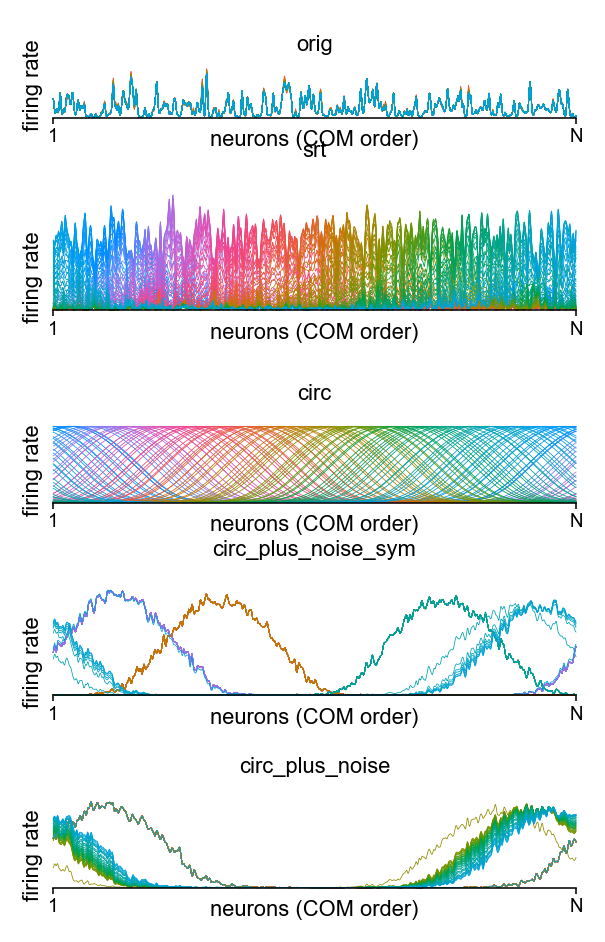

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(3, 5))
fig.subplots_adjust(hspace=1)

for i, key in enumerate(matrix_keys):
    plot_simulation_results(axes[i], sim_results[key], key)
    axes[i].set_ylim(0, 6)


## Eigenvalue spectra of the surrogates (writes `surrogate_spectra.npz`)

Spectra of the five matrices. `calc_spectra()` only runs when `REGENERATE_CACHES = True` for the same reason. These spectra do not appear in Figure 2; the section remains as a check on the surrogates.

orig
srt
circ
circ_plus_noise_sym
circ_plus_noise


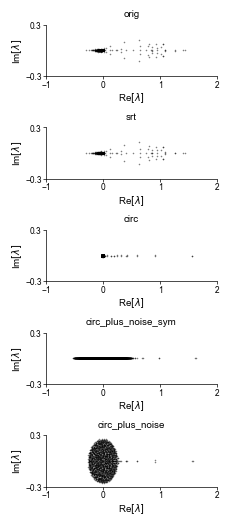

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def calc_spectra():
    spectra_results = {}    
    for key in matrix_keys:
        M = mat_results[key]
        w = np.linalg.eigvals(M)
        spectra_results[key] = w
    np.savez('../data/surrogate_spectra.npz', **spectra_results)

if REGENERATE_CACHES:
    calc_spectra()

spectra_results = np.load('../data/surrogate_spectra.npz')

def plot_spectrum(ax, w, title, xlim=(-0.8, 1.6), ylim=(-0.3, 0.3)):
    ax.scatter(w.real, w.imag, lw=0, s=1.25, clip_on=False, c='black', alpha=0.5)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_yticks(ylim)
    ax.set_xticks([-1, 0, 1, 2])
    ax.set_aspect(1.5)
    ax.set_xlabel("Re$[\\lambda]$")
    ax.set_ylabel("Im$[\\lambda]$")
    ax.set_title(title)


fig, axes = plt.subplots(5, 1, figsize=(5, 6), dpi=100)
fig.subplots_adjust(hspace=1)

for i, key in enumerate(matrix_keys):
    print(key)
    plot_spectrum(axes[i], spectra_results[key], key)

plt.show()

## Velocity integration (writes `velocity_integration_sims.npz`)

Drives the network with `J_prime` under two angular-velocity signals, a constant step and the real ω(t) from the mouse, and records m(θ, t) against the integrated target HD. `run_analysis()` only runs when `REGENERATE_CACHES = True`; the cache is 1.4 GB and is the largest in the project.

In [11]:
# analysis_closing_loop.py

import numpy as np
from scipy.interpolate import interp1d
from ring import data_driven

def run_analysis():
    # Load head direction data
    hd, omega, data_dt = data_driven.load_hd_and_omega() 
    omega_interp = interp1d(np.arange(len(omega))*data_dt, omega)

    # Set up simulation parameters
    T, tau = 110, 0.05
    T_eval = tau / 5.
    dt = tau / 50.
    
    # Define omega functions
    omega_funcs = [
        lambda t: 0.8*(t > 20.),  # Step function
        omega_interp  # Real head direction signal
    ]

    # Run simulations and save key results
    results = []
    for i, omega_func in enumerate(omega_funcs):
        # Run simulation
        x_save = data_driven.run_simulation(
            J=J, x_init=X[0:1].T, T=T, tau=tau, dt=dt, T_eval=T_eval, 
            J_prime=J_prime, omega_func=omega_func
        )
        
        # Compute activity heatmap
        m = data_driven.compute_m(data_driven.nonlin(x_save), Phi)

        # Resample omega at correct times
        t = np.arange(len(m)+1)*T_eval
        omega_rs = omega_func(t)

        # Integrate
        hd_target = np.cumsum(omega_rs) * T_eval

        # Shave off 20 s at the beginning of each
        skip_amt = int(20 / T_eval)
        m = m[skip_amt:]
        hd_target = hd_target[skip_amt:]
        
        # Store minimal results needed for plotting
        results.append({
            'm': m,
            'hd_target': hd_target,
            'sim_params': {
                'T': T - 20,
                'T_eval': T_eval
            }
        })
        
    # Save head direction data and simulation results
    np.savez('../data/velocity_integration_sims.npz',
             hd=hd,
             omega=omega,
             data_dt=data_dt,
             results=results)

if REGENERATE_CACHES:
    run_analysis()

integration_sim_data = np.load('../data/velocity_integration_sims.npz', 'r', allow_pickle=True)
integration_sim_results = integration_sim_data['results']


## Closing the loop: the data-side projection (Fig 2, panel l)

Loads `data/closing_the_loop.npz`, produced by `closing_the_loop.ipynb`. `remove_discontinuities_mod_2pi` is applied *here*, on load. The cache stores the raw wrapped trace so that the correction runs exactly once.

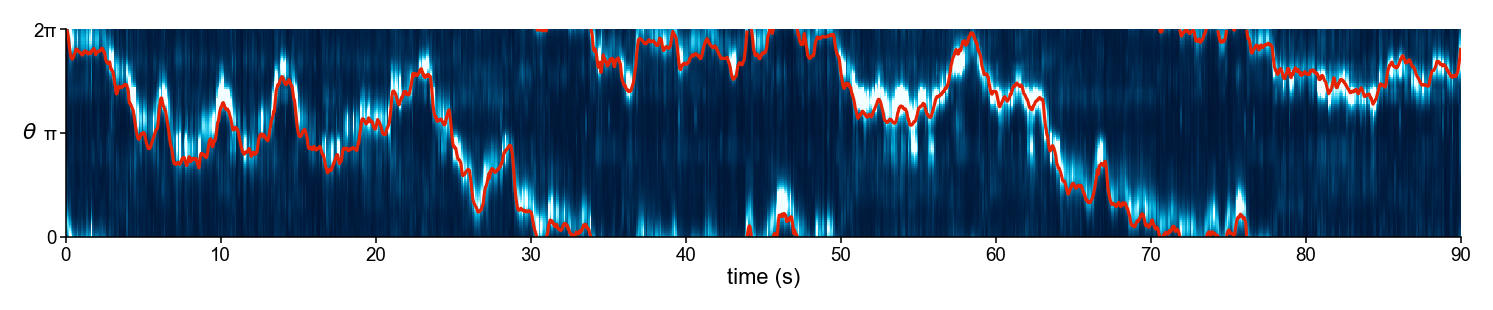

In [12]:

# Closing the loop
def plot_ctl(ax):
    ctl_data = np.load("../data/closing_the_loop.npz", "r")
    m_ctl, hd_ctl, m_dt, hd_dt = [ctl_data[k] for k in ('m', 'hd', 'm_dt', 'hd_dt')]
    
    hd_ctl = data_driven.remove_discontinuities_mod_2pi(hd_ctl)
    
    data_driven.plot_head_direction(
        ax, m=m_ctl[:, :900].T, hd=hd_ctl, m_dt=m_dt, hd_dt=hd_dt
    )

fig, ax = plt.subplots(1,1,figsize=(8,1.2))
plot_ctl(ax)

## Heatmaps: simulated and measured bumps side by side (Fig 2, panels j–l)

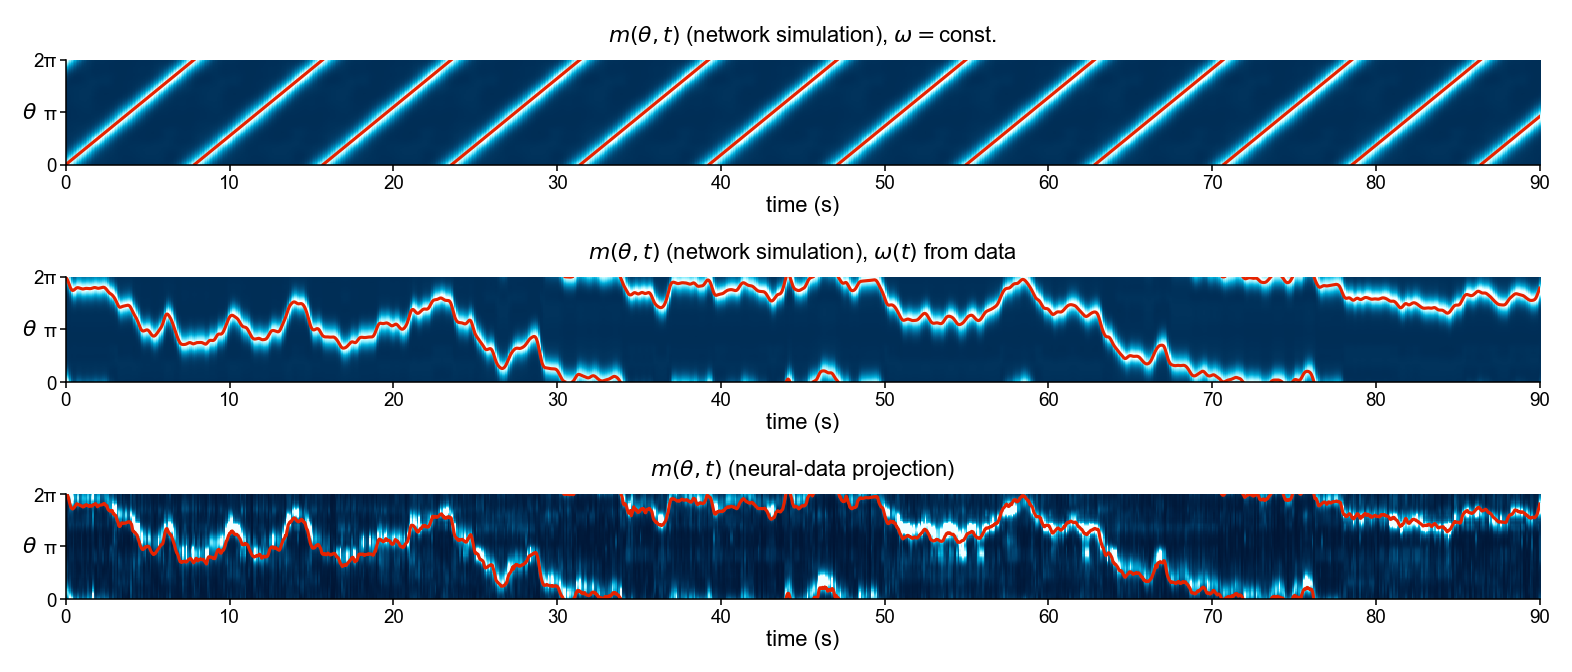

In [13]:
# plot_closing_loop.py

import numpy as np
import matplotlib.pyplot as plt
from ring import data_driven

def plot_integration_sim_hetamaps(axes):
    for i, ax in enumerate(axes):
        sim_params = integration_sim_results[i]['sim_params']
        
        hd_dt = sim_params['T_eval']
        m_dt = hd_dt
        hd = data_driven.remove_discontinuities_mod_2pi(integration_sim_results[i]['hd_target'])
        m = integration_sim_results[i]['m'][...,0]

        m = m[::10, ::20]
        m_dt *= 10
        
        data_driven.plot_head_direction(axes[i], m, hd, m_dt, hd_dt)

def plot_heatmaps(axes):
    plot_integration_sim_hetamaps(axes[:2])
    plot_ctl(axes[2])
    axes[0].set_title("$m(\\theta,t)$ (network simulation), $\\omega=$const.")
    axes[1].set_title("$m(\\theta,t)$ (network simulation), $\\omega(t)$ from data")
    axes[2].set_title("$m(\\theta,t)$ (neural-data projection)")

fig, axes = plt.subplots(3, 1, figsize=(7, 3))
plot_heatmaps(axes)
plt.tight_layout()
plt.show()

## Assemble Figure 2

Lays out all twelve panels and writes `../figures/data_driven_attractor.pdf`. The `plt.savefig` only runs when `SAVE_FIGURES = True`.

1533
7.181859639735274
1533
4.764863398407756
1533
5.376581864618627


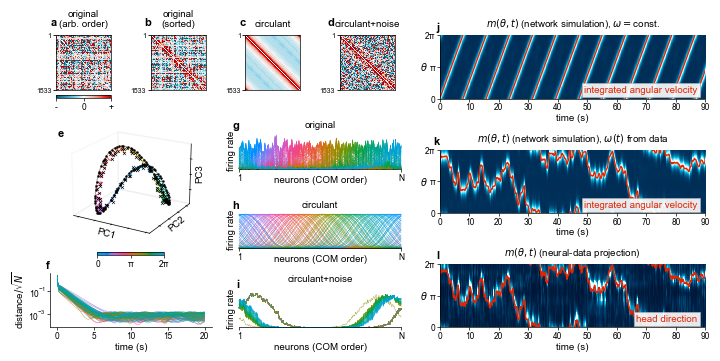

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create figure with specific size
fig = plt.figure(figsize=(style.FULL_W, style.TALL_H), dpi=100)

# Create the main horizontal split into 3 sections
# Centred: left and 1-right are equal, so the axes block sits centred on the
# canvas. Both move together, so the block width is unchanged and no panel is
# resized.
gs_main = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1.7], left=0.055, right=0.965, bottom=0.065, top=0.90)

# Create nested GridSpecs for the left two columns combined (shared vertical divisions)
gs_left = gridspec.GridSpecFromSubplotSpec(4, 4, subplot_spec=gs_main[0:2], hspace=0.45, wspace=0.4)

# Create nested GridSpec for the rightmost column (independent vertical divisions)
gs_right = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs_main[2], hspace=0.8)

# Left columns (shared structure)
# Top row
ax_arb = fig.add_subplot(gs_left[0, 0])
ax_sorted = fig.add_subplot(gs_left[0, 1])
ax_circ = fig.add_subplot(gs_left[0, 2])
ax_circ_noise = fig.add_subplot(gs_left[0, 3])

# # Second row

# 3D plot and convergence plots
ax_3d = fig.add_subplot(gs_left[1:3, 0:2], projection='3d')  # Spans 2 rows in left column
ax_convg1 = fig.add_subplot(gs_left[1, 2:4])  # Aligned with top of 3D
ax_convg2 = fig.add_subplot(gs_left[2, 2:4])  # Aligned with bottom of 3D

# Bottom row
ax_dist_conv = fig.add_subplot(gs_left[3, 0:2])  # Left column
ax_convg3 = fig.add_subplot(gs_left[3, 2:4])     # Center column, aligned with distances converging

# Right column (independent structure)
ax_heatmap1 = fig.add_subplot(gs_right[0])
ax_heatmap2 = fig.add_subplot(gs_right[1])
ax_heatmap3 = fig.add_subplot(gs_right[2])

plot_heatmaps([ax_heatmap1, ax_heatmap2, ax_heatmap3])

# Label the red line (integrated angular velocity) in panels J, K, L. The line
# is otherwise unlabeled and readers keep asking what it is. A nearly-opaque white
# chip in the bottom-right corner keeps the red text legible over the viridis heatmap.
for hax, _lab in ((ax_heatmap1, "integrated angular velocity"),
                  (ax_heatmap2, "integrated angular velocity"),
                  (ax_heatmap3, "head direction")):
    hax.text(0.97, 0.06, _lab, transform=hax.transAxes,
             color=style.HD_COLOR, fontsize=7, va='bottom', ha='right', zorder=5,
             bbox=dict(boxstyle='square,pad=0.25', facecolor='white', alpha=0.9,
                       edgecolor='0.7', linewidth=0.5))

im_arb = plot_weight_matrix(ax_arb, mat_results['orig'], "original\n(arb. order)")
plot_weight_matrix(ax_sorted, mat_results['srt'], "original\n(sorted)")
plot_weight_matrix(ax_circ, mat_results['circ'], "circulant")
plot_weight_matrix(ax_circ_noise, mat_results['circ_plus_noise'], "circulant+noise")

# Add colorbar below ax_arb
cax_arb = ax_arb.inset_axes([0, -0.15, 1, style.CBAR_THICK])
vmax = np.abs(im_arb.get_clim()).max()
cbar_arb = fig.colorbar(im_arb, cax=cax_arb, orientation='horizontal', ticks=[-vmax, 0, vmax])
cbar_arb.outline.set_linewidth(0.5)
cax_arb.set_xticklabels(['-', '0', '+'], fontsize=6)


plot_pcs(ax_3d)
cax = ax_3d.inset_axes([0.25, -0.05, 0.5, style.CBAR_THICK / 2.2])
norm = plt.Normalize(0, 2*np.pi)
sm = plt.cm.ScalarMappable(cmap=angle_cmap, norm=norm)
sm.set_array(np.linspace(0, 2*np.pi, 100))  # Dummy array
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', ticks=[0, np.pi, 2*np.pi])
cbar.outline.set_linewidth(0.5)
cax.set_xticklabels(['0', 'π', '2π'])

# Title-height multipliers for the firing-rate panels (I stays at the 1.3 default).
# G and H have faint thin top strands, so their titles read as floating too high above
# the visible curve mass; nudge those two titles down to match panel I's spacing.
TITLE_Y_G = 1.15
TITLE_Y_H = 1.15
plot_distances(ax_dist_conv)
plot_simulation_results(ax_convg1, sim_results['srt'], "original", titlepad=-5, title_y=TITLE_Y_G)
plot_simulation_results(ax_convg2, sim_results['circ'], "circulant", titlepad=0, title_y=TITLE_Y_H)
plot_simulation_results(ax_convg3, sim_results['circ_plus_noise'], "circulant+noise", titlepad=0)

# Add subplot labels with customized positions
def add_label(ax, label, x=-0.2, y=1.15):  # Default position further out
    if hasattr(ax, 'get_zlim'): # Check if it's a 3D plot
        ax.text2D(x, y, label, transform=ax.transAxes,
                fontsize=8, fontweight='bold', va='bottom', ha='right')
    else:
        ax.text(x, y, label, transform=ax.transAxes,
                fontsize=8, fontweight='bold', va='bottom', ha='right')

# Label all subplots with custom positions where needed
add_label(ax_arb, 'a', x=0, y=1.15)
add_label(ax_sorted, 'b', x=0, y=1.15)
add_label(ax_circ, 'c', x=0, y=1.15)
add_label(ax_circ_noise, 'd', x=-0.1, y=1.15)


add_label(ax_3d, 'e', x=0., y=0.82)

add_label(ax_dist_conv, 'f', x=0, y=1.05)

add_label(ax_convg1, 'g', x=0., y=0.7)
add_label(ax_convg2, 'h', x=0., y=0.7)
add_label(ax_convg3, 'i', x=0., y=0.7)


add_label(ax_heatmap1, 'j', x=0.0, y=1.05)
add_label(ax_heatmap2, 'k', x=0.0, y=1.05)
add_label(ax_heatmap3, 'l', x=0.0, y=1.05)

if SAVE_FIGURES:
    plt.savefig("../figures/data_driven_attractor.pdf", dpi=400)
plt.show()